In [ ]:
import os

import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from torchvision import transforms
from tqdm.auto import tqdm

from copy import deepcopy

import matplotlib.pyplot as plt

import sqlite3
import pandas as pd

import subprocess
from datetime import datetime

import ipywidgets as widgets
from IPython.display import display

import json

from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import EMBEDS_DIR, RESULTS, DB_PATH, MODELS
from src.model_selection import get_checkpoints, load_inference_models

EMBED_PATH = EMBEDS_DIR/ "cont_embeds.pt"
EMBED_NAME = EMBED_PATH.stem

RESULTS_DIR = RESULTS / EMBED_NAME

MODEL_DIR = MODELS / "anomaly_head"

In [2]:
os.makedirs(MODEL_DIR, exist_ok=True)

In [3]:
contrastive_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [4]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT path, split
    FROM meta
""", conn)

categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()
types = pd.read_sql_query("SELECT DISTINCT type FROM meta", conn)["type"].to_list()

conn.close()

train_paths = df[df["split"] == "train"]["path"].to_list()
test_paths = df[df["split"] != "train"]["path"].to_list()

In [5]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

2.12.0+cu130
13.0
True
1
Device: cuda


In [6]:
DINO_DIR = MODELS / "dino_fine_tune"
CATHEAD_DIR = MODELS / "category_head"

dino_checkpoints = get_checkpoints(DINO_DIR)
cathead_checkpoints = get_checkpoints(CATHEAD_DIR)


print(f"Found {len(dino_checkpoints)} fine-tuned DINO checkpoints")
print(f"Found {len(cathead_checkpoints)} category-head checkpoints")

Found 1 fine-tuned DINO checkpoints
Found 18 category-head checkpoints


In [ ]:
use_category_head = widgets.Checkbox(
    value=False,
    description="Use category head",
)

dino_selector = widgets.Dropdown(
    options=[
        ("Select a DINO model", "UNSELECTED"),
        ("Pretrained DINOv2 ViT-S/14", None),
        *[
            (path.name, path)
            for path in dino_checkpoints
        ],
    ],
    value="UNSELECTED",
    description="DINO:",
    layout=widgets.Layout(width="800px")
)

category_head_selector = widgets.Dropdown(
    options=[
        ("Select a category head", None),
        *[
            (path.name, path)
            for path in cathead_checkpoints
        ],
    ],
    value=None,
    description="Category head:",
    layout=widgets.Layout(width="800px")
)

confirm_button = widgets.Button(
    description="Confirm selection",
    button_style="success",
    layout=widgets.Layout(width="180px")
)

selection_output = widgets.Output()

selection_confirmed = False

selected_use_category_head: bool | None = None
selected_dino_path: Path | None | str = "UNSELECTED"
selected_category_head_path: Path | None = None

In [8]:
def update_model_selectors(change: dict[str, object] | None = None) -> None:
    if use_category_head.value:
        dino_selector.layout.display = "none"
        category_head_selector.layout.display = ""
    else:
        dino_selector.layout.display = ""
        category_head_selector.layout.display = "none"


def confirm_selection(_: widgets.Button) -> None:
    global selection_confirmed
    global selected_use_category_head
    global selected_dino_path
    global selected_category_head_path

    selection_output.clear_output()

    with selection_output:
        if use_category_head.value:
            if category_head_selector.value is None:
                print("Select a category head first.")
                return

            selected_use_category_head = True
            selected_dino_path = None
            selected_category_head_path = category_head_selector.value

        else:
            if dino_selector.value == "UNSELECTED":
                print("Select a DINO model first.")
                return

            selected_use_category_head = False
            selected_dino_path = dino_selector.value
            selected_category_head_path = None

        selection_confirmed = True

        print("Selection confirmed.")


use_category_head.observe(update_model_selectors, names="value")

confirm_button.on_click(confirm_selection)

update_model_selectors()

display(
    use_category_head,
    dino_selector,
    category_head_selector,
    confirm_button,
    selection_output
)

Checkbox(value=False, description='Use category head')

Dropdown(description='DINO:', layout=Layout(display='', width='800px'), options=(('Select a DINO model', 'UNSE…

Dropdown(description='Category head:', layout=Layout(display='none', width='800px'), options=(('Select a categ…

Button(button_style='success', description='Confirm selection', layout=Layout(width='180px'), style=ButtonStyl…

Output()

In [10]:
if (
    not selection_confirmed
    or selected_use_category_head is None
):
    raise RuntimeError(
        "Execution stopped: choose a model, click "
        "'Confirm model selection', then run this cell "
        "or use 'Run All Below'."
    )

In [ ]:
if selected_category_head_path is None:
    pipeline = load_inference_models(selected_dino_path, device=device)
else:
    pipeline = load_inference_models(selected_category_head_path, device=device)
    
print("Models Selected")
print("------------------------")
print(f"DINO: {pipeline.dino_path}")
print(f"Category head: {pipeline.category_head_path}")

Models Selected
------------------------
DINO: None
Category head: None


In [ ]:
inf_models = pipeline.models

print(f"Loaded inference pipeline containing {len(inf_models)} model(s)")

Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Using pretrained DINOv2 ViT-S/14
Loaded inference pipeline containing 1 model(s)


In [13]:
%load_ext autoreload 
%autoreload 2 

from src.fine_tune import ModelData, ProjectionHead, BatchSampler, NegativeSampler, train_one_epoch, evaluate 
from src.fine_tune.losses.anomaly_head.combined_loss import CombinedLoss 

git_commit = subprocess.check_output( ["git", "rev-parse", "HEAD"], text=True ).strip()

In [ ]:
LOSSES = {
    "cont_loss" : True
}

WEIGHTS = {
  "cont_loss" : 1.0
}

NOTES = [
    "Using fine tuned dino for embedding no category projection head"
]

SEED = 42

NUM_WORKERS = 8
PIN_MEMORY = device.type == "cuda"
SAMPLES_PER_CATEGORY = 16

BATCH_SIZE = len(categories) * SAMPLES_PER_CATEGORY

EPOCHS = 20

DIM = 384
HIDDEN_DIM = 768

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

MODEL_NORMALISER = "layer"

MODEL_NAME = "model.pt"

In [ ]:
MODEL_INFO = {
    "losses" : LOSSES,
    "weights" : WEIGHTS,
    "notes" : NOTES,
    "git_commit" : git_commit,
    "parameters" : {
        "batch_size" : BATCH_SIZE,
        "epochs" : EPOCHS,
        "samples_per_category" : SAMPLES_PER_CATEGORY,

        "model_dim" : DIM,
        "hidden_dim": HIDDEN_DIM,
        "model_normaliser": MODEL_NORMALISER,

        "learning_rate" : LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        
        "num_workers" : NUM_WORKERS,
        "pin_memory" : PIN_MEMORY,

        "random_seed" : SEED
    },
    "parent_models" : {
        "dino" : str(pipeline.dino_path),
        "category_head" : str(pipeline.category_head_path)
    }
}

In [16]:
category_to_id = {category: idx for idx, category in enumerate(categories)}
types_to_id = {type: idx for idx, type in enumerate(types)}

dataset = ModelData(train_paths, root=ROOT, category_to_id=category_to_id, types_to_id=None, transform=contrastive_transform)
test_set = ModelData(test_paths, root=ROOT, category_to_id=category_to_id, types_to_id=types_to_id, transform=test_transform)

train_split = int(len(dataset) * 0.95)
val_split = len(dataset) - train_split

generator = torch.Generator().manual_seed(SEED)

train_set, val_set = random_split(
    dataset,
    [train_split, val_split],
    generator=generator
)

train_labels = [dataset.category_ids[i] for i in train_set.indices]
val_labels = [dataset.category_ids[i] for i in val_set.indices]

train_sampler = BatchSampler(
    labels=train_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=None
)

val_sampler = BatchSampler(
    labels=val_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=SEED
)

test_labels = test_set.cat_types_ids

negative_sampler = NegativeSampler(
    labels=test_labels,
    samples_per_cat=5,
    types_to_id=types_to_id,
    seed=SEED
)

train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_set,
    batch_sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Need to change this to remove the negative samples due to data leakage
test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [17]:
neg_indices = negative_sampler.get_negatives()

neg_images: list[torch.Tensor] = []
neg_labels: list[int] = []

for idx in neg_indices:
    view1, _, category_id, _ = test_set[idx]

    neg_images.append(view1)
    neg_labels.append(category_id)

neg_image_ten = torch.stack(neg_images).to(device)
neg_labels_ten = torch.tensor(
    neg_labels,
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    neg_embeds: torch.Tensor = neg_image_ten
    for model in inf_models:
        neg_embeds = model(neg_embeds)

In [18]:
model = ProjectionHead(dim=DIM, hidden_dim=HIDDEN_DIM, norm_type=MODEL_NORMALISER).to(device)

optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = CombinedLoss(enabled=LOSSES, weights=WEIGHTS, negatives=neg_embeds, negative_labels=neg_labels_ten)

In [ ]:
results = pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "gap"])

best_val = float("inf")
best_state = None

try:    
    for epoch in tqdm(range(EPOCHS)):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, inf_models=inf_models)
        val_loss = evaluate(model, val_loader, criterion, device, inf_models=inf_models)

        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())
            
        results.loc[len(results)] = {
            "epoch": epoch+1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "gap": abs(val_loss - train_loss)
        }
        
        print(results.tail(1).to_string(
            index=False,
            header=(epoch==0)
        ) + "\n")

finally:
    if best_state is not None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        EXP_DIR = MODEL_DIR / timestamp

        os.makedirs(EXP_DIR, exist_ok=False)

        checkpoint = {
            "model_state_dict" : best_state,
            "parameters" : MODEL_INFO["parameters"],
            "parent_models" : MODEL_INFO["parent_models"]
        }

        torch.save(checkpoint, EXP_DIR / MODEL_NAME)

        with open(EXP_DIR / "metadata.json", "w") as f:
            json.dump(MODEL_INFO, f, indent=4)

        results.to_csv(EXP_DIR / "train_history.csv", index=False)

        print(f"Best Model Saved (val_loss={best_val:.4f})")

  0%|          | 0/20 [00:00<?, ?it/s]

 epoch  train_loss  val_loss      gap
     1    3.633011  3.562328 0.070683

2 3.525197 3.494443 0.030754

3 3.475392 3.457187 0.018205

4 3.456043 3.452306 0.003737

5 3.450279 3.448805 0.001473

6 3.447644 3.452725 0.00508

7 3.447115 3.451014 0.003899

8 3.446393 3.450592 0.004199

9 3.445035 3.444939 0.000096

10 3.446107 3.446745 0.000639

11 3.444848 3.443639 0.001208

12 3.444001 3.444338 0.000337

13 3.443464 3.446728 0.003263

14 3.445425 3.445625 0.0002

15 3.444706 3.446801 0.002095

16 3.44464 3.445863 0.001223

17 3.443379 3.444803 0.001425

18 3.442881 3.443728 0.000847

19 3.443022 3.443578 0.000556

20 3.442721 3.443352 0.000631

Best Model Saved (val_loss=3.4434)


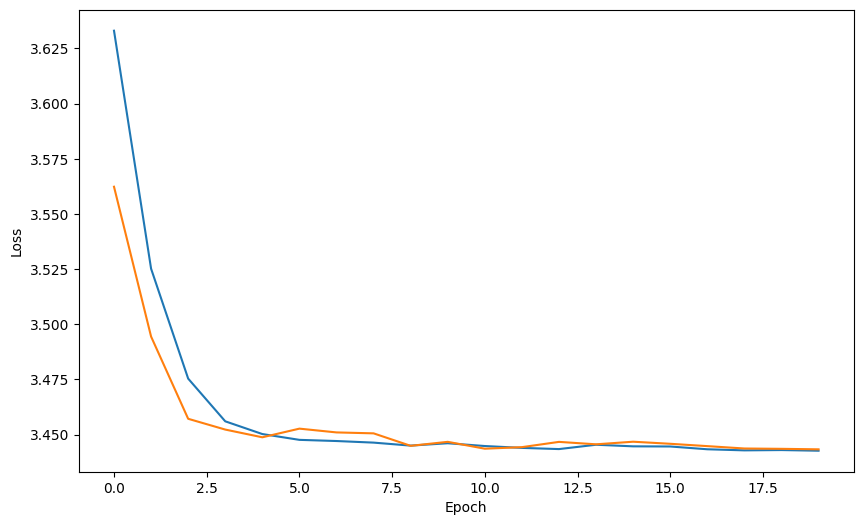

In [20]:
fig = plt.figure(figsize=(10, 6))

plt.plot(range(EPOCHS), results["train_loss"])
plt.plot(range(EPOCHS), results["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()